# Differentiating Between States

This experiment demonstrates how Qblox can take data points and assign them to different qubit states, based on demodulated IQ signals. Connect O1 and O2 to I1 and I2 respectively of the Qblox QRM module.

Note:\
	->Signals are demodulated before integrating, but the scope acquisition is NOT demodulated.\
	->Signal travel time is important, make sure the cable lengths for path 0 and 1 are the same, otherwise you'll notice
		an offset between the signal on the order of nanoseconds.\
	->Final integration result is HALF the actual waveform average value. This part of how Qblox modulates and demodulates signals.\

This experiment is based on the Qblox conditional playback tutorial:
https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/tutorials/q1asm_tutorials/intermediate/conditional_playback.html 

Authors: Noah Stieler, Luke Dyer

#### Excerpt from Qblox NCO tutorial:
https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/tutorials/q1asm_tutorials/basic/baseband/nco_control.html

#### Modulation

The NCO modulates the AWG output with a certain frequency, such that we only need to store the envelope of any waveform to create a wave with the correct frequency and phase. To enable IQ up- and down-conversion to RF frequencies, the device will generate a phase shifted signal on both signal paths.

If modulation is enabled, the value of the NCO ($e^{i\omega t}$) will be multiplied by the awg outputs ($z(t) = \text{awg}_0 + i \cdot \text{awg}_1$), and also by a factor of $1 / \sqrt{2}$ to prevent clipping, and forwarded to path 0/1 as follows:

\begin{equation*}
\text{path}_{0, \text{out}} = \frac{1}{\sqrt{2}}(\cos(\omega t)\text{awg}_0 - \sin(\omega t)\text{awg}_1)
\end{equation*}

\begin{equation*}
\text{path}_{1, \text{out}} =  \frac{1}{\sqrt{2}}(\sin(\omega t)\text{awg}_0 + \cos(\omega t)\text{awg}_1)
\end{equation*}

These two outputs can then be used within a QxM-RF module or by an external IQ mixer to generate RF pulses. Each path, 0/1, will have two components (real and imaginary) referred to as I and Q. However, the NCO can also be operated in real mode which will create a direct modulated output.

#### Demodulation

Usually, we are interested in the envelope of the acquired signal instead of the oscillating values, in particular when integrating. Therefore, the NCO can also be used to demodulate the signal before integration.

If demodulation is enabled, the signal is again multiplied with the NCO(effectively $e^{-i\omega t}$ during demodulation), this time also with a factor of $1 / \sqrt{2}$. Both in modulation and demodulation the mixed NCO $\sin$ and $\cos$ terms have a maximum amplitude of $1 / \sqrt{2}$ to prevent clipping.

This leads to an amplitude factor of $1 / \sqrt{2}\times 1 / \sqrt{2}$ = 0.5 when demodulating your output signal. Internally, this is accounted for in the datapaths to allow maximum dynamic range:

\begin{equation*}
\text{path}_{0, \text{in}} = \frac{1}{\sqrt{2}}(\cos(\omega t)\, \text{in}_0 + \sin(\omega t)\, \text{in}_1) = \frac{1}{\sqrt{2}}\left(\frac{1}{\sqrt{2}}\cos(\omega t) \cdot \cos(\omega t)\, \text{awg}_0 + \frac{1}{\sqrt{2}}\sin(\omega t) \cdot \sin(\omega t)\, \text{awg}_0\right) = \frac{1}{2}\text{awg}_0
\end{equation*}

\begin{equation*}
\text{path}_{1, \text{in}} = \frac{1}{\sqrt{2}}(-\sin(\omega t)\, \text{in}_0 + \cos(\omega t)\, \text{in}_1) = \frac{1}{\sqrt{2}}\left(\frac{1}{\sqrt{2}}\sin(\omega t) \cdot \sin(\omega t)\, \text{awg}_1 + \frac{1}{\sqrt{2}}\cos(\omega t) \cdot \cos(\omega t)\, \text{awg}_1\right) = \frac{1}{2}\text{awg}_1
\end{equation*}

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
from qblox_instruments import Cluster
from qblox_instruments.types import InstrumentType

In [2]:
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
cluster = Cluster("cluster_mm", "192.168.137.2")
moduleQRM = None
moduleQCM = None

modules = [mod for mod in cluster.modules if mod.present()]
for mod in modules:
	print(str(mod) + " type=" + str(mod.module_type) + " is_rf_type=" + str(mod.is_rf_type))

cluster.reset()
cluster.get_system_state()

moduleQRM = modules[1]

<QcmQrm: cluster_mm_module2 of Cluster: cluster_mm> type=QCM is_rf_type=False
<QcmQrm: cluster_mm_module4 of Cluster: cluster_mm> type=QRM is_rf_type=False
<QcmQrm: cluster_mm_module6 of Cluster: cluster_mm> type=QCM is_rf_type=True


In [4]:
#state1_Q amplitude is set differently to mimic response that a different state would produce in something like
#an RF reflectometry measurement.

tof = 144	#Time of flight in nanoseconds, see timeOfFlightComp.ipynb to detemine it.

waveformLength = 120
t = np.arange(-80, 81, 1)
sigma = 20
waveforms = {
	"zero": {"data": [0.0] * 1024, "index": 0},
	"one": {"data": [1.0] * 1024, "index": 1},
	"state0_I": {"data": [0.001] * waveformLength, "index": 2},
	"state0_Q": {"data": [0.001] * waveformLength, "index": 3},
	"state1_I": {"data": [0.001] * waveformLength, "index": 4},
	"state1_Q": {"data": [0.003] * waveformLength, "index": 5},
	"gauss": {"data": list(np.exp(-(0.5 * t**2 / sigma**2))), "index": 6},
	"empty": {"data": list(0.0 * t), "index": 7}
}
acquisitions = {
	"state0": {"index": 0, "num_bins": 1024}, #Each bin stores an integration result
	"state1": {"index": 1, "num_bins": 1024}
}

integrationLength = 120
moduleQRM.sequencer0.integration_length_acq(integrationLength)
moduleQRM.sequencer0.sync_en(True)
moduleQRM.sequencer0.nco_freq(50e6)	#This sets the modulation frequency
moduleQRM.sequencer0.mod_en_awg(True)
moduleQRM.sequencer0.demod_en_acq(True)
moduleQRM.scope_acq_sequencer_select(0)
moduleQRM.scope_acq_trigger_mode_path0("sequencer")
moduleQRM.scope_acq_trigger_mode_path1("sequencer")
moduleQRM.disconnect_inputs()
moduleQRM.disconnect_outputs()
moduleQRM.sequencer0.connect_sequencer("io0_1")

1.4598843893503046


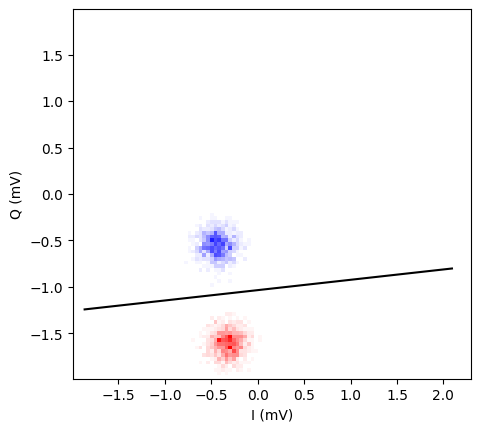

In [5]:
#Store the integrated result of each modulated signal, and repeat 1024 times
sequenceProgram = f"""
	move			0,R0

	start:
		play		2,3,{tof}
		acquire		0,R0,{waveformLength}
		play		4,5,{tof}
		acquire	1,R0,{waveformLength}
		add			R0,1,R0
		wait		4000
		jlt			R0,1024,@start
		
	upd_param	4
	stop

"""

sequence = {
	"waveforms": waveforms,
	"weights": {},
	"acquisitions": acquisitions,
	"program": sequenceProgram
}
moduleQRM.sequencer0.sequence(sequence)

moduleQRM.arm_sequencer(0)
moduleQRM.start_sequencer()

moduleQRM.get_acquisition_state(0, 1)
moduleQRM.store_scope_acquisition(0, "state0")
moduleQRM.store_scope_acquisition(0, "state1")
data = moduleQRM.get_acquisitions(0)

#We don't take the actual integration values (ie state0/integration length) because the only relevant
#information here is the difference between the two states, not the actual data points themselves.
state0 = np.array(data["state0"]["acquisition"]["bins"]["integration"]["path0"]) + 1j *np.array(
	data["state0"]["acquisition"]["bins"]["integration"]["path1"])
state1 = np.array(data["state1"]["acquisition"]["bins"]["integration"]["path0"]) + 1j *np.array(
	data["state1"]["acquisition"]["bins"]["integration"]["path1"])

#Rotation and threshold values define a line which delineates between state0 and state1
#The rotation value is the angle measured from the vertical axis, the threshold is the length of the
#vector that is normal to the line, starting at the origin.

#More information: https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/cluster/q1_sequence_processor.html

#Modulo operation is to ensure final angle is on the interval [0, 2pi].
rotation = np.mod(-np.angle(np.mean(state1) - np.mean(state0)), 2 * np.pi)
print(rotation)

#Once vetical line has been rotated, it needs to be offset. We rotate the mean
#vector of the two points to get the threshold. To understand this, instead of thinking of
#rotating the vector in the CCW direction, instead rotate the IQ axis in the CW direction. Then 
#the distance between the mean and the rotated line is the real part of the mean.
averageVec = (np.mean(state1) + np.mean(state0))/2
threshold = (np.exp(1j*rotation) * averageVec).real

#Plotting the histogram
scaling = 1000 / integrationLength
maxr = max(np.max(np.abs(state0)), np.max(np.abs(state1)))
hist0, xedges, yedges = np.histogram2d(
    state0.real, state0.imag, range=((-maxr, maxr), (-maxr, maxr)), bins=100
)
hist1, xedges, yedges = np.histogram2d(
    state1.real, state1.imag, range=((-maxr, maxr), (-maxr, maxr)), bins=100
)

plt.imshow(
    1 - np.array((hist0, hist0 + hist1, hist1)).transpose(2, 1, 0) / np.max(hist0 + hist1),
    extent=(-maxr * scaling, maxr * scaling, -maxr * scaling, maxr * scaling),
    origin="lower",
)
plt.plot(
    ((1j * xedges + threshold) * np.exp(-1j * rotation)).real * scaling,
    ((1j * xedges + threshold) * np.exp(-1j * rotation)).imag * scaling,
    "k",
)
plt.xlabel("I (mV)")
plt.ylabel("Q (mV)")
plt.show()

#### Run acquisition now that we can differentiate between states

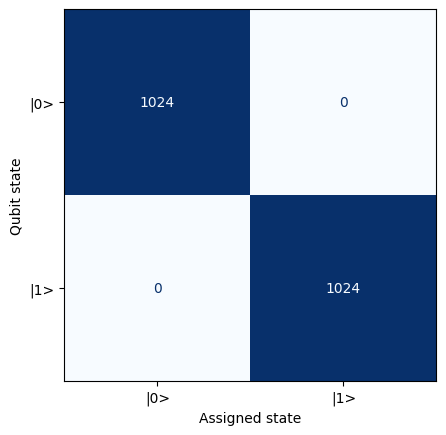

In [6]:
moduleQRM.sequencer0.thresholded_acq_threshold(threshold)
moduleQRM.sequencer0.thresholded_acq_rotation(rotation * 360 / (2*np.pi))

moduleQRM.sequencer0.delete_acquisition_data(all=True)
moduleQRM.sequencer0.arm_sequencer()
moduleQRM.sequencer0.start_sequencer()

moduleQRM.get_acquisition_state(0, 1)
data = moduleQRM.get_acquisitions(0)

confusionMatrix = [
	[
        np.sum(np.array(data["state0"]["acquisition"]["bins"]["threshold"]) == 0),
		np.sum(np.array(data["state0"]["acquisition"]["bins"]["threshold"]) == 1),
	],
	[
		np.sum(np.array(data["state1"]["acquisition"]["bins"]["threshold"]) == 0),
		np.sum(np.array(data["state1"]["acquisition"]["bins"]["threshold"]) == 1),
	],
]

#Plot the confusion matrix
p = plt.matshow(confusionMatrix, cmap="Blues", vmin=0, vmax=1024)
ax = plt.gca()
for i in [0, 1]:
    for j in [0, 1]:
        ax.annotate(
            confusionMatrix[i][j],
            xy=(j, i),
            horizontalalignment="center",
            verticalalignment="center",
            color=p.cmap(1024 - confusionMatrix[i][j]),
        )
plt.xlabel("Assigned state")
plt.ylabel("Qubit state")
plt.xticks([0, 1], ["|0>", "|1>"])
plt.yticks([0, 1], ["|0>", "|1>"])
ax.xaxis.set_ticks_position("bottom")
plt.show()